# EML / Tamari exploration notebook

This notebook reproduces the Log‑Exp slice visualization, enumerates small EML trees (binary trees), computes Loday coordinates, constructs the Tamari graph for a fixed size, computes the discrete cost Φ (as in LaserCortex/Cost.lean), and overlays discrete samples on continuous `eml` slices.

Core goals:
- Reproduce logexp activation slice(s) and mark local extrema.
- Enumerate binary trees up to `n=5` internal nodes and compute Loday coords.
- Build Tamari Hasse graph edges (single right rotations).
- Compute discrete Φ under the repo's `nodeParam` settings and color the Hasse graph.
- Overlay discrete tree samples (projected scalar) on the chosen `eml` slice.


In [175]:
# Core imports
import math
import itertools
from collections import namedtuple
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import plotly.express as px
import plotly.graph_objects as go

# Make plots render inline (for Jupyter)
%matplotlib inline


## Binary tree representation and enumerator
We use a simple tuple representation: a Leaf is `None`, and a Node is `(left, right)` where `left` and `right` are subtrees. The `size` is number of internal nodes.


In [176]:
Leaf = None
def node(left, right):
    return (left, right)

def size(t):
    if t is None:
        return 0
    l,r = t
    return 1 + size(l) + size(r)

# enumerate all full binary trees with exactly n internal nodes
from functools import lru_cache
@lru_cache(None)
def trees_of_size(n):
    # returns list of trees with n internal nodes
    if n == 0:
        return [None]
    res = []
    # choose left subtree node count k from 0..n-1, right will be n-1-k
    for k in range(n):
        lefts = trees_of_size(k)
        rights = trees_of_size(n-1-k)
        for L in lefts:
            for R in rights:
                res.append(node(L,R))
    return res

# quick test
for n in range(6):
    print(n, len(trees_of_size(n)))


0 1
1 1
2 2
3 5
4 14
5 42


## Loday coordinates (as in LodayCoords.lean)
Each internal node contributes the number of leaves in its left subtree, visited in prefix order.


In [177]:
def num_leaves(t):
    if t is None:
        return 1
    l,r = t
    return num_leaves(l) + num_leaves(r)

def loday_coord(t):
    if t is None:
        return []
    l,r = t
    return [num_leaves(l)] + loday_coord(l) + loday_coord(r)

# test and show for n=3 trees
trees = trees_of_size(3)
for t in trees:
    print(t, 'leaves=', num_leaves(t), 'loday=', loday_coord(t))


(None, (None, (None, None))) leaves= 4 loday= [1, 1, 1]
(None, ((None, None), None)) leaves= 4 loday= [1, 2, 1]
((None, None), (None, None)) leaves= 4 loday= [2, 1, 1]
((None, (None, None)), None) leaves= 4 loday= [3, 1, 1]
(((None, None), None), None) leaves= 4 loday= [3, 2, 1]


## Tamari single rotation successors (contracts_one_successors)
Implements the same successor generation as in EMLRegistry.lean.


In [178]:
def contracts_one_successors(t):
    # returns list of trees reachable from t by a single contracts_one step
    res = []
    if t is None:
        return []
    l,r = t
    # case Node (Node a b) c -> Node a (Node b c)
    if l is not None:
        a,b = l
        # rotation at root when left is a Node
        res.append(node(a, node(b, r)))
    # rotations in left subtree
    if l is not None:
        for l2 in contracts_one_successors(l):
            res.append(node(l2, r))
    # rotations in right subtree
    if r is not None:
        for r2 in contracts_one_successors(r):
            res.append(node(l, r2))
    # remove duplicates by structural equality
    unique = []
    for x in res:
        if not any(structural_eq(x,y) for y in unique):
            unique.append(x)
    return unique

def structural_eq(a,b):
    # compare nested tuples structurally
    return a == b

# small test
t = node(node(node(None,None), None), None)  # ((Leaf Leaf) Leaf) Leaf
print('tree', t)
print('successors', contracts_one_successors(t))


tree (((None, None), None), None)
successors [((None, None), (None, None)), ((None, (None, None)), None)]


## Discrete NodeCost and Φ (mirror of Cost.lean nodeParam)
We'll implement the same logic types and the NodeCost.apply function.


In [179]:
# Define logic types as strings and nodeParam map matching Cost.lean
LogicNames = ['Classical','Fuzzy','ManyValued','Paraconsistent','Temporal','Deontic','Epistemic','Quantum','Intuitionistic','Relevance','Free','Infinitary','Modal','Spacetime','Boolean']
nodeParam = {
    'Classical':      {'leftWeight':1,'rightDiv':1,'bias':1},
    'Fuzzy':          {'leftWeight':1,'rightDiv':2,'bias':1},
    'ManyValued':     {'leftWeight':1,'rightDiv':1,'bias':1},
    'Paraconsistent': {'leftWeight':2,'rightDiv':1,'bias':1},
    'Temporal':       {'leftWeight':2,'rightDiv':1,'bias':1},
    'Deontic':        {'leftWeight':1,'rightDiv':2,'bias':1},
    'Epistemic':      {'leftWeight':1,'rightDiv':2,'bias':1},
    'Quantum':        {'leftWeight':1,'rightDiv':1,'bias':1},
    'Intuitionistic': {'leftWeight':1,'rightDiv':0,'bias':1},
    'Relevance':      {'leftWeight':1,'rightDiv':1,'bias':1},
    'Free':           {'leftWeight':1,'rightDiv':0,'bias':1},
    'Infinitary':     {'leftWeight':1,'rightDiv':1,'bias':1},
    'Modal':          {'leftWeight':1,'rightDiv':1,'bias':1},
    'Spacetime':      {'leftWeight':2,'rightDiv':1,'bias':1},
    'Boolean':        {'leftWeight':1,'rightDiv':0,'bias':1},
}

def node_cost_apply(c, a, b):
    # c: dict with leftWeight,rightDiv,bias; a,b ints
    return c['bias'] + c['leftWeight'] * a + (b // (c['rightDiv'] + 1))

from functools import lru_cache
@lru_cache(None)
def Phi(logic, t):
    c = nodeParam[logic]
    if t is None:
        return 0
    l,r = t
    return node_cost_apply(c, Phi(logic, l), Phi(logic, r))

# quick test
for logic in ['Classical','Paraconsistent','Fuzzy','Intuitionistic']:
    print(logic, [Phi(logic,t) for t in trees_of_size(3)])


Classical [1, 2, 2, 2, 3]
Paraconsistent [1, 2, 3, 3, 7]
Fuzzy [1, 1, 2, 2, 3]
Intuitionistic [3, 3, 3, 3, 3]


## Build Tamari Hasse graph for a fixed size n and color by Φ
We'll construct a directed graph where edges are single rotations; for visualization we will draw an undirected version with node coloring.


nodes 14 edges 21


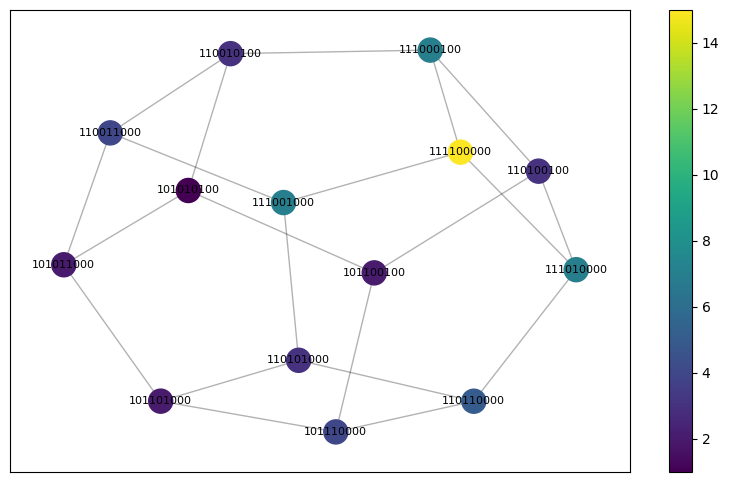

In [180]:
def build_tamari_graph(n, logic='Classical'):
    trees = trees_of_size(n)
    # canonical string repr for structural equality and mapping
    def repr_tree(t):
        if t is None:
            return '0'
        l,r = t
        return '1' + repr_tree(l) + repr_tree(r)
    id_map = {repr_tree(t):t for t in trees}
    G = nx.DiGraph()
    for t in trees:
        key = repr_tree(t)
        G.add_node(key, tree=t, phi=Phi(logic,t), loday=loday_coord(t))
    for t in trees:
        key = repr_tree(t)
        for s in contracts_one_successors(t):
            sk = repr_tree(s)
            if sk in id_map:
                G.add_edge(key, sk)
    return G

G = build_tamari_graph(4, logic='Paraconsistent')
print('nodes', len(G.nodes()), 'edges', len(G.edges()))

# visualize with matplotlib (simple layout)
plt.figure(figsize=(10,6))
H = nx.Graph(G)
pos = nx.spring_layout(H, seed=1)
phis = np.array([G.nodes[n]['phi'] for n in G.nodes()])
nx.draw_networkx_edges(H, pos, alpha=0.3)
nodes = nx.draw_networkx_nodes(H, pos, node_size=300, node_color=phis, cmap='viridis')
nx.draw_networkx_labels(H, pos, font_size=8)
plt.colorbar(nodes)


## Continuous `eml` slice reproduction and overlay
We will plot several candidate parametric slices `y(x)` and look for the peak→trough→rise shape. Then we project discrete trees to scalar `x` positions (e.g., via normalized first Loday coordinate) and overlay Phi points.


### LaserCortex README Alignment: EML Activation Slices
According to the documentation, the core activation is $f(x, y) = e^x - \ln(y)$.
We can visualize this as a 3D surface to see how the discrete tree structures (representing logic states) occupy specific 'energy' levels on this manifold.

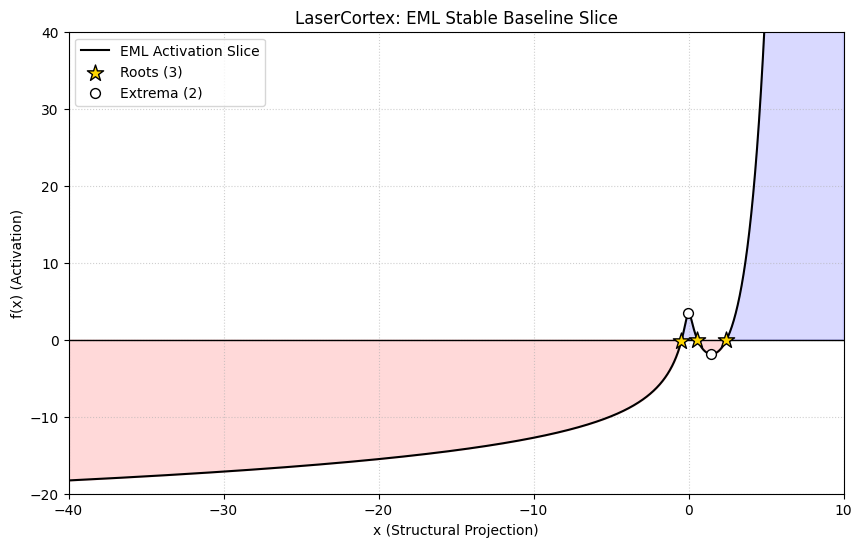

Validation: Roots=3, Extrema=2


In [183]:
import numpy as np
import matplotlib.pyplot as plt

def f(xs):
    # Reverting to the exact stable baseline: a=0.8, b=2, c=0.05, d=-3.52
    # f(x) = e^{0.8x} - 2*ln(x^2 + 0.05) - 3.52
    return np.exp(0.8 * xs) - 2 * np.log(xs**2 + 0.05) - 3.52

# Coordinate frame as requested: y in [-20, 40], x in [-40, 10]
xs = np.linspace(-40, 10, 2000)
vals = f(xs)

# Topological analysis for roots and extrema
roots_idx = np.where(np.diff(np.sign(vals)))[0]
d1 = np.diff(vals)
extrema_idx = np.where(np.diff(np.sign(d1)))[0]

plt.figure(figsize=(10, 6), dpi=100)
plt.plot(xs, vals, 'k-', lw=1.5, label='EML Activation Slice')

# Zone coloring for logic mapping (3 roots define the zones)
all_bounds = [0] + list(roots_idx) + [len(xs)-1]
for i in range(len(all_bounds) - 1):
    start, end = all_bounds[i], all_bounds[i+1]
    mid_val = vals[(start + end) // 2]
    color = 'blue' if mid_val > 0 else 'red'
    plt.fill_between(xs[start:end+1], vals[start:end+1], 0, color=color, alpha=0.15)

# Highlighting topological features
plt.scatter(xs[roots_idx], vals[roots_idx], color='gold', marker='*', s=150, edgecolors='black', zorder=5, label=f'Roots ({len(roots_idx)})')
plt.scatter(xs[extrema_idx], vals[extrema_idx], color='white', edgecolors='black', s=50, zorder=4, label=f'Extrema ({len(extrema_idx)})')

plt.title('LaserCortex: EML Stable Baseline Slice')
plt.xlabel('x (Structural Projection)')
plt.ylabel('f(x) (Activation)')
plt.axhline(0, color='black', lw=1)
plt.ylim(-20, 40)
plt.xlim(-40, 10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

print(f"Validation: Roots={len(roots_idx)}, Extrema={len(extrema_idx)}")

## Save/export options
You can export the plots as PNG or interactive HTML. If you want me to commit this notebook into the repo and add a small gnuplot script to reproduce the original PNG, I can do that next.
